In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re

In [11]:
ctd_data_folder = Path('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/')

In [ ]:
for path in sorted(p for p in ctd_data_folder.glob("*_nav*.csv") if re.search(r'_nav\d*\.csv$', p.name)):
    data = pd.read_csv(path)
    
    data['datetime'] = pd.to_datetime(data['date'])

    data = data.set_index('datetime').resample('15s').mean(numeric_only=True).reset_index()
    
    peak_idx = data['depth'].idxmax()
    downcast = data.loc[:peak_idx]
    
    downcast.to_csv(ctd_data_folder / f"{path.stem}_15s_downcast.csv", index=False)
    
    downcast_1400 = downcast.loc[downcast['depth'] >= 1400]
    downcast_1400.to_csv(ctd_data_folder / f"{path.stem}_15s_downcast_1400.csv", index=False)

In [80]:
ctd19 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_011_nav2.csv')
ctd19['datetime'] = pd.to_datetime(ctd19['date'])

(40.0, 120.0)

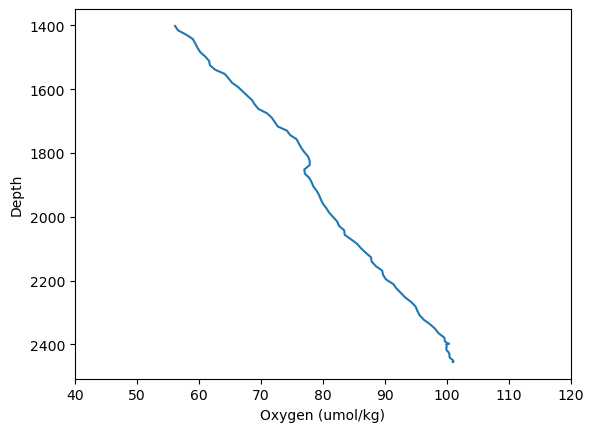

In [84]:
ctd19['datetime'] = pd.to_datetime(ctd19['date'])
ctd19_resample = ctd19.set_index('datetime').resample('15s').mean(numeric_only=True).reset_index()
ctd19_cut = ctd19_resample.loc[ctd19_resample['depth'] >= 1400]
idx_19 = ctd19_cut['depth'].idxmax()
downcast_19 = ctd19_cut.loc[:idx_19]

plt.plot(downcast_19['oxygenumolkg'], downcast_19['depth'])
plt.gca().invert_yaxis()
plt.xlabel('Oxygen (umol/kg)')
plt.ylabel('Depth')
plt.xlim(40,120)

(40.0, 120.0)

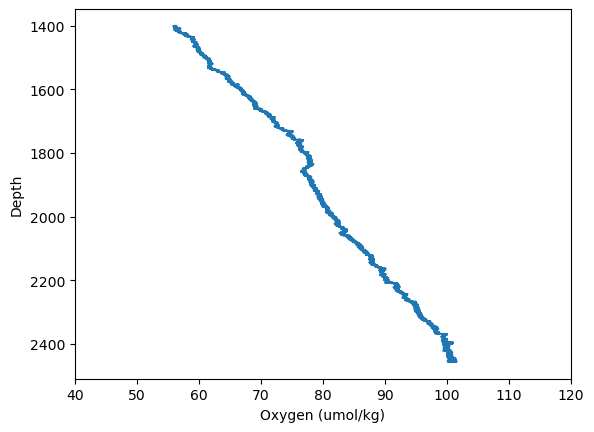

In [78]:
ctd19 = pd.read_csv('/Users/Sam/Documents/Postdoc/Cruise/Processed CTD Data/at5036_011_nav2.csv')

ctd19_cut = ctd19.loc[ctd19['depth'] >= 1400]
idx_19 = ctd19_cut['depth'].idxmax()
downcast_19 = ctd19_cut.loc[:idx_19]

plt.plot(downcast_19['oxygenumolkg'], downcast_19['depth'])
plt.gca().invert_yaxis()
plt.xlabel('Oxygen (umol/kg)')
plt.ylabel('Depth')
plt.xlim(40,120)